In [2]:
import pandas as pd
import numpy as np

import nltk
nltk.download('popular')
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('stopwords')

from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/jovyan/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to

In [10]:
def lemmatize_text(text):
    '''
    Lemmatizes the provided string and returns it.
    @param text : a string of unlemmatized text
    @return a lemmatized string
    '''
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word.lower()) for word in text.split()]
    return ' '.join(lemmatized_words)


def remove_stop_words(text):
    '''
    Removes stop words from the provided string and returns it.
    @param text : a string that contains stop words
    @return a string without stop words
    '''
    stop_words = set(stopwords.words('english'))
    filtered_sentence = [word for word in text.split() if word not in stop_words]
    return ' '.join(filtered_sentence)


def get_tfidf_by_book(target_word, odyssey_df):
    '''
    Computes the tfidf scores of the target word for each book in the Odyssey, 
    then adds those scores as a new column in the dataframe.

    @param target_word : the word to calculate TF-IDF for
    @param odyssey_df : a dataframe with the text of the odyssey in a column named 'content'
    @return the provided dataframe with an additional column named tfidf_targetword that contains the tf-idf scores

    Here is an example:
    - To call the function: odyssey_df = get_tfidf_by_book("home", odyssey_df)
    - To access the computed scores: odyssey_df['tfidf_home']
    '''
    # Initialize the vectorizer with the whole vocabulary
    vectorizer = TfidfVectorizer()

    # Fit and transform the 'content' column
    tfidf_matrix = vectorizer.fit_transform(odyssey_df['content'])

    # Get the index of the target word in the vocabulary
    try:
        word_index = vectorizer.vocabulary_[target_word]
        # Extract the TF-IDF scores for that word across all rows
        tfidf_scores = tfidf_matrix[:, word_index].toarray().flatten()
        # Add as a new column to the DataFrame
        odyssey_df[f'tfidf_{target_word}'] = tfidf_scores * 100
    except KeyError:
        # Word not found in the vocabulary
        odyssey_df[f'tfidf_{target_word}'] = 0.0

    # Display the DataFrame
    print(odyssey_df)
    return odyssey_df

def get_wordfreq_by_book(target_word, df):
    """
    Counts the frequency of a target word per book and adds it as a new column.

    @param target_word : str, the word to count (case-insensitive)
    @param df : pandas DataFrame, must contain a 'content' column with book text
    - content: str, name of the column with text data (default is 'content')

    @return the original DataFrame with a new column added
    """
    word_counts_list = []

    for text in df['content']:
        words = text.lower().split()  # lowercase to count "Shame" and "shame"
        count = sum(1 for word in words if word.strip(".,;?!\"'") == target_word.lower())
        word_counts_list.append(count)

    df[f'{target_word}_freq'] = word_counts_list
    return df


def get_clean_odyssey_data():
    '''
    Pipeline to load Odyssey data into a dataframe, lemmatize it, remove stop words, and return as a dataframe.
    @return a dataframe containing preprocessed text
    '''
    odyssey_df = pd.read_csv('odyssey.csv')
    odyssey_df['content'] = odyssey_df['content'].apply(lemmatize_text)
    odyssey_df['content'] = odyssey_df['content'].apply(remove_stop_words)
    return odyssey_df

ody_df = get_clean_odyssey_data() # cleaned text data frame
freq_df = get_wordfreq_by_book("shame", ody_df)
freq_df = get_wordfreq_by_book("wrath", ody_df)
freq_df

,Unnamed: 0,book,content,shame_freq,wrath_freq
0,0,1,tell muse man many device wandered full many w...,1,3
1,1,2,soon early dawn appeared rosyfingered bed aros...,2,3
2,2,3,sun leaving beauteous mere sprang brazen heave...,2,2
3,3,4,came hollow land lacedaemon many ravine drove ...,1,1
4,4,5,dawn arose couch beside lordly tithonus bear l...,0,3
5,5,6,lay asleep muchenduring goodly odysseus overco...,0,0
6,6,7,prayed muchenduring goodly odysseus two strong...,1,2
7,7,8,soon early dawn appeared rosyfingered strong m...,2,1
8,8,9,odysseus many wile answered said lord alcinous...,0,3
9,9,10,aeolian isle came dwelt aeolus son hippotas de...,0,0


([<matplotlib.axis.XTick at 0x7fc54b994740>,
 [Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6'),
  Text(7.0, 0, '7'),
  Text(8.0, 0, '8'),
  Text(9.0, 0, '9'),
  Text(10.0, 0, '10'),
  Text(11.0, 0, '11'),
  Text(12.0, 0, '12'),
  Text(13.0, 0, '13'),
  Text(14.0, 0, '14'),
  Text(15.0, 0, '15'),
  Text(16.0, 0, '16'),
  Text(17.0, 0, '17'),
  Text(18.0, 0, '18'),
  Text(19.0, 0, '19'),
  Text(20.0, 0, '20'),
  Text(21.0, 0, '21'),
  Text(22.0, 0, '22'),
  Text(23.0, 0, '23'),
  Text(24.0, 0, '24')])

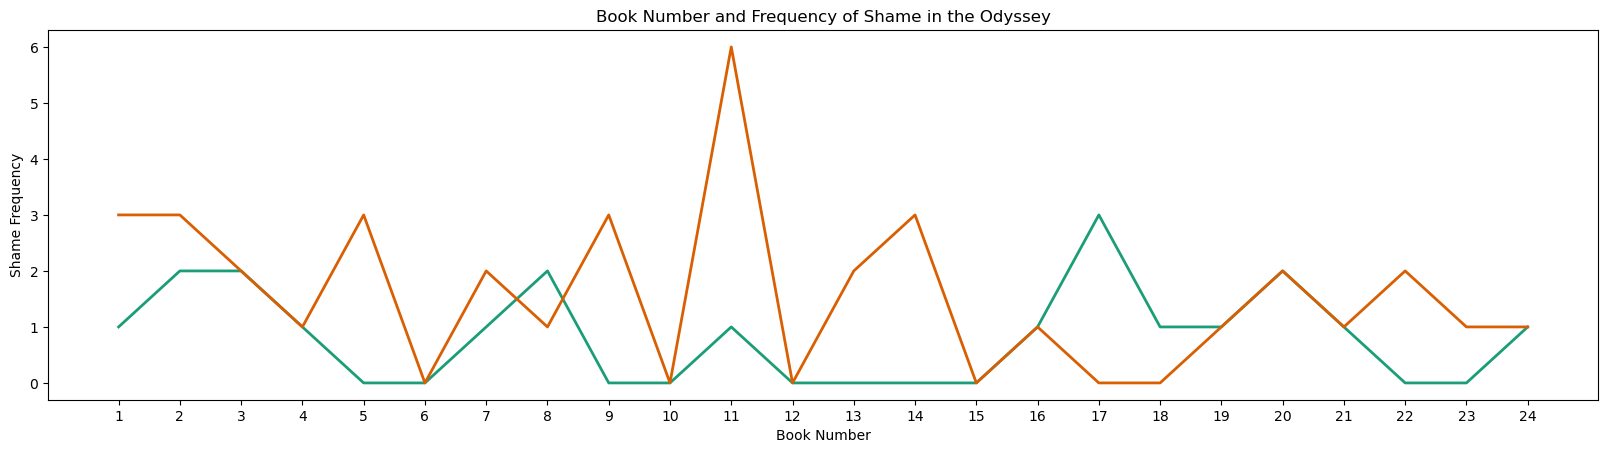

In [11]:
fig, ax = plt.subplots()
fig.set_figwidth(20) # increase width of graph
x = freq_df['book']
y1 = freq_df['shame_freq']
y2 = freq_df["wrath_freq"]
colors = ["#1B9E77", "#D95F02", "#7570B3", "#1d35e1","#e11dc6" ]
ax.plot(x, y1, label='shame', color=colors[0], linewidth=2)
ax.plot(x, y2, label='wrath', color=colors[1], linewidth=2)


ax.set_title("Book Number and Frequency of Shame in the Odyssey")
ax.set_xlabel("Book Number")
ax.set_ylabel("Shame Frequency")
plt.xticks(np.arange(min(x), max(x)+1, 1.0)) # set intervals of 1 for the x axis